# 03 — R-Peak Detection (Pan-Tompkins-style)

Building the pipeline stage by stage: derivative -> squaring -> moving-window integration -> peak detection. This notebook starts with just the derivative stage.

## Load and filter the record

Same record and filter as `02_signal_processing.ipynb`.

In [2]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

RECORD_NAME = "100"

record = wfdb.rdrecord(RECORD_NAME, pn_dir="mitdb")
fs = record.fs
lead_index = record.sig_name.index("MLII") if "MLII" in record.sig_name else 0
ecg_signal = record.p_signal[:, lead_index]
time = np.arange(len(ecg_signal)) / fs


def bandpass_filter(signal, lowcut, highcut, fs, order=4):
    """Zero-phase Butterworth bandpass filter for ECG."""
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype="band")
    return filtfilt(b, a, signal)


filtered_signal = bandpass_filter(ecg_signal, lowcut=0.5, highcut=40, fs=fs, order=4)

## Stage 1: Derivative

Approximates the local slope (rate of change) of the signal at each sample.
We use `np.gradient`, which computes a central difference (using the
neighboring sample on each side) and divides by the true sample spacing
`1/fs`, giving output in physically meaningful units (mV/s) rather than raw
per-sample differences. This is a simplified stand-in for the weighted
5-point derivative used in the original Pan-Tompkins paper — good enough
for our purposes, and easy to swap out later if needed.

In [3]:
def derivative_filter(signal, fs):
    """Approximate slope (dV/dt) of the signal using a central difference."""
    return np.gradient(signal, 1 / fs)


derivative_signal = derivative_filter(filtered_signal, fs)

## Filtered ECG vs its derivative

**What to look for:** the P and T waves, which change gently, should almost
flatten out in the derivative. The QRS complex, which rises and falls in a
few tens of milliseconds, should produce a sharp positive-then-negative
spike pair and nothing else in the signal should come close to that
magnitude.

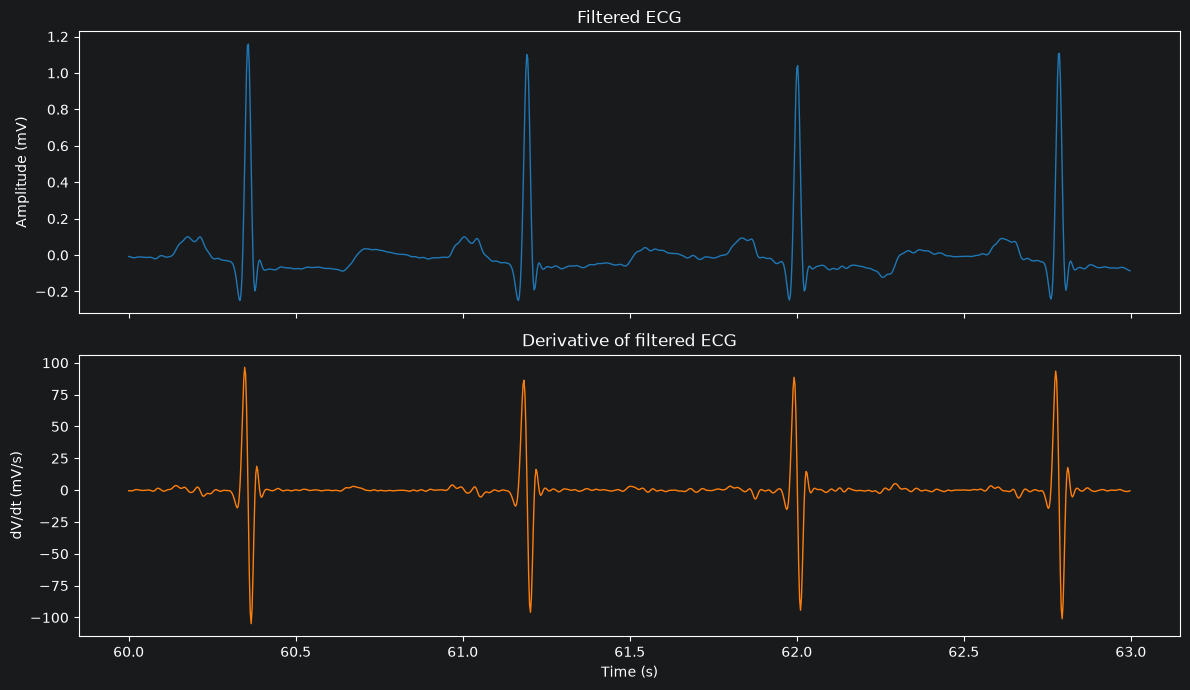

In [4]:
zoom_start, zoom_end = 60, 63  # seconds
mask = (time >= zoom_start) & (time < zoom_end)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(time[mask], filtered_signal[mask], color="tab:blue", linewidth=1.0)
axes[0].set_title("Filtered ECG")
axes[0].set_ylabel("Amplitude (mV)")

axes[1].plot(time[mask], derivative_signal[mask], color="tab:orange", linewidth=1.0)
axes[1].set_title("Derivative of filtered ECG")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("dV/dt (mV/s)")

fig.tight_layout()
fig.savefig("../results/figures/04_derivative.png", dpi=120)
plt.show()

## Stage 2: Squaring

Every sample is replaced by its own square: `y[n] = derivative[n]**2`.

Two things happen at once:
- **Everything becomes positive.** The derivative had a positive spike (rising
  into the R peak) and a negative spike (falling out of it) — squaring
  removes the sign, so both become tall positive spikes instead of one up and
  one down. This matters because the next stages (moving-window integration,
  peak-finding) are built to find *tall positive bumps*, not to reason about
  sign.
- **Large values are amplified far more than small ones.** Squaring a
  derivative value of 100 gives 10,000; squaring a value of 5 gives only 25.
  So the genuine QRS-driven spike, which was already much larger than the
  background jitter, gets stretched even further above it — a cheap,
  nonlinear contrast boost, not just a sign fix.

In [6]:
squared_signal = derivative_signal ** 2

## Derivative vs squared derivative

**What to look for:** the small background wiggles between beats, still
faintly visible in the derivative, should flatten to essentially zero here.
Each QRS should now show up as two adjacent tall positive spikes (one from
the up-slope, one from the down-slope — both positive now) rather than one
up and one down.

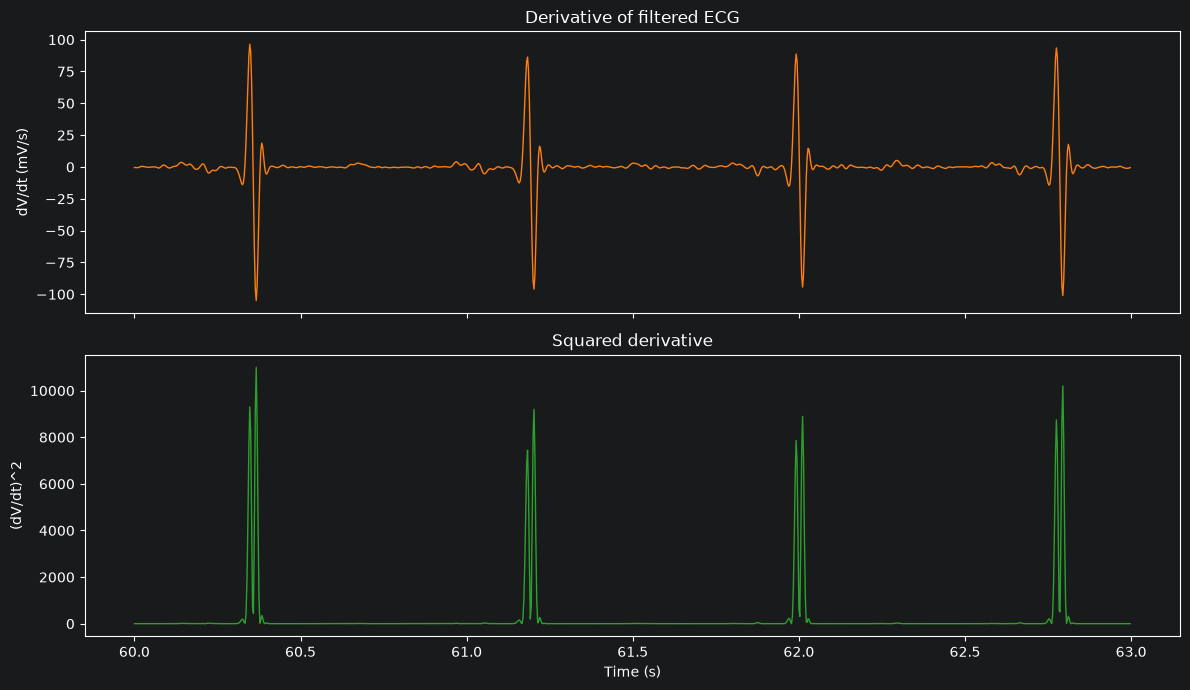

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(time[mask], derivative_signal[mask], color="tab:orange", linewidth=1.0)
axes[0].set_title("Derivative of filtered ECG")
axes[0].set_ylabel("dV/dt (mV/s)")

axes[1].plot(time[mask], squared_signal[mask], color="tab:green", linewidth=1.0)
axes[1].set_title("Squared derivative")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("(dV/dt)^2")

fig.tight_layout()
fig.savefig("../results/figures/05_squared.png", dpi=120)
plt.show()

## Stage 3: Moving-window integration

A moving-window integration is a moving average: each output sample is the
mean of the last `N` samples, `y[n] = (1/N) * sum(x[n-N+1 .. n])`. It's
literally a running estimate of the area under the squared-derivative curve
over a short sliding window, normalized by `N` so the result stays on a
comparable scale regardless of window size.

**Why it helps:** right now the squared signal has two narrow spikes per
beat (from the QRS's up-slope and down-slope). A window *narrower* than
their separation would leave them as two separate bumps; a window at least
as wide as the whole QRS blends them into a single, wider pulse representing
the QRS's total energy — exactly what you predicted before we built this.

**Choosing the window size from `fs`, not a hardcoded number:** the window
needs to be about as wide as a QRS complex itself (~100-120 ms — the same
duration we used earlier to compute the 36-sample answer). Too short and the
two spikes don't fully merge; too long and it starts blending in energy from
*outside* the QRS, and at high heart rates could even smear two separate
beats together. So the window is computed as `round(qrs_duration_seconds *
fs)` — this is why the calculation is expressed in seconds and converted via
`fs`, rather than writing `36` directly: the same code then produces the
correct window size for a record at a different sampling frequency.

In [ ]:
def moving_window_integration(signal, window_size):
    """Moving average (boxcar) over `window_size` samples, same length as input."""
    kernel = np.ones(window_size) / window_size
    return np.convolve(signal, kernel, mode="same")


qrs_duration_seconds = 0.1  # ~100ms, consistent with the earlier RR/window derivation
window_size = int(round(qrs_duration_seconds * fs))
print(f"fs={fs} Hz, qrs_duration={qrs_duration_seconds*1000:.0f}ms -> window_size={window_size} samples")

integrated_signal = moving_window_integration(squared_signal, window_size)

## Squared derivative vs integrated signal

**What to look for:** each pair of tall narrow spikes should now be one
wider pulse. Don't expect a perfectly smooth single peak — a boxcar
(uniform-weight) moving average produces a flat-topped plateau, sometimes
with a slight ripple where the original two spikes had different heights.
That's fine: there's still exactly one dominant region per beat, which is
all the next stage (peak detection) needs.

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(time[mask], squared_signal[mask], color="tab:green", linewidth=1.0)
axes[0].set_title("Squared derivative")
axes[0].set_ylabel("(dV/dt)^2")

axes[1].plot(time[mask], integrated_signal[mask], color="tab:red", linewidth=1.2)
axes[1].set_title(f"Moving-window integration (window={window_size} samples, ~{qrs_duration_seconds*1000:.0f}ms)")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Integrated energy")

fig.tight_layout()
fig.savefig("../results/figures/06_integrated.png", dpi=120)
plt.show()